In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.transform import rotate
import os
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from typing import Callable, Literal
from torch import Tensor
from PIL import Image
from torch.utils.data import Dataset
import multiprocessing as mp

mp.set_start_method("forkserver", force=True) 

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

### Problem 1: Train the data on first 20 classes

In [3]:
DATA_ROOT = "Oxford-IIIT-Pet-Dataset"
IMG_DIR   = os.path.join(DATA_ROOT, "images")
ANN_DIR   = os.path.join(DATA_ROOT, "annotations")

IMG_SIZE = 224
BATCH_SIZE = 32

# ── Parse annotation files ──
def parse_annotation(filepath):
    """Returns list of (image_name, class_id) tuples. class_id is 1-indexed."""
    entries = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            img_name = parts[0]
            class_id = int(parts[1])
            entries.append((img_name, class_id))
    return entries

train_entries = parse_annotation(os.path.join(ANN_DIR, "trainval.txt"))
test_entries  = parse_annotation(os.path.join(ANN_DIR, "test.txt"))

def class_name_from_filename(fname):
    parts = fname.split("_")
    return "_".join(parts[:-1])

id_to_name = {}
for img_name, cid in train_entries:
    if cid not in id_to_name:
        id_to_name[cid] = class_name_from_filename(img_name)

all_class_ids = sorted(id_to_name.keys())            
base_class_ids = all_class_ids[:20]                   
new_class_ids  = all_class_ids[20:]                   

print(f"Total classes : {len(all_class_ids)}")
print(f"Base classes  : {len(base_class_ids)}  ->  {[id_to_name[c] for c in base_class_ids]}")
print(f"New classes   : {len(new_class_ids)}   ->  {[id_to_name[c] for c in new_class_ids]}")


Total classes : 37
Base classes  : 20  ->  ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger']
New classes   : 17   ->  ['Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


In [4]:
from torch.utils.data import Dataset

class PetDataset(Dataset):
    """
    entries : list of (image_name, original_class_id)
    class_ids : list of class ids to keep (acts as filter + remapping)
    """
    def __init__(self, entries, class_ids, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.id_to_label = {cid: idx for idx, cid in enumerate(sorted(class_ids))}
        self.samples = [(name, cid) for name, cid in entries if cid in self.id_to_label]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, cid = self.samples[idx]
        img_path = os.path.join(self.img_dir, img_name + ".jpg")
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.id_to_label[cid]
        return image, label

# ── Transforms ──
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Use all of trainval.txt as training set for base 20 classes ──
train_dataset_base = PetDataset(train_entries, base_class_ids, IMG_DIR, train_transform)
test_dataset_base  = PetDataset(test_entries,  base_class_ids, IMG_DIR, test_transform)

# num_workers=0 to avoid multiprocessing pickle errors on macOS Jupyter
train_loader_base = DataLoader(train_dataset_base, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader_base  = DataLoader(test_dataset_base,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Base train samples: {len(train_dataset_base)}")
print(f"Base test  samples: {len(test_dataset_base)}")


Base train samples: 1985
Base test  samples: 1981


In [5]:
# ── Problem 1: Build ResNet18 from scratch (no pretrained weights) ──

NUM_BASE_CLASSES = len(base_class_ids)   # 20

# ResNet18 without pretrained weights
resnet18 = models.resnet18(weights=None)

# Replace the final FC layer for 20 classes
feat_dim = resnet18.fc.in_features       # 512
resnet18.fc = nn.Linear(feat_dim, NUM_BASE_CLASSES)

resnet18 = resnet18.to(device)
print(f"Feature dimension (f): {feat_dim}")
print(f"Classifier G0 shape : ({NUM_BASE_CLASSES}, {feat_dim})")
print(resnet18)


Feature dimension (f): 512
Classifier G0 shape : (20, 512)
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [60]:
# ── Problem 1: Train ResNet18 on base 20 classes ──

NUM_EPOCHS = 40
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

train_losses, train_accs = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    resnet18.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader_base, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet18(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    scheduler.step()
    print(f"Epoch {epoch:02d} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")

    #Save Model checkpoint for best training accuracy
    if epoch_acc == max(train_accs):
        torch.save(resnet18.state_dict(), "resnet18_base20.pth")


Epoch 1/40:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 3.0843 | Train Acc: 9.27%


Epoch 2/40:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 2.8644 | Train Acc: 13.25%


Epoch 3/40:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 38 | Train Loss: 1.0491 | Train Acc: 68.72%


Epoch 39/40:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 39 | Train Loss: 1.0378 | Train Acc: 68.51%


Epoch 40/40:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 40 | Train Loss: 1.0223 | Train Acc: 70.28%


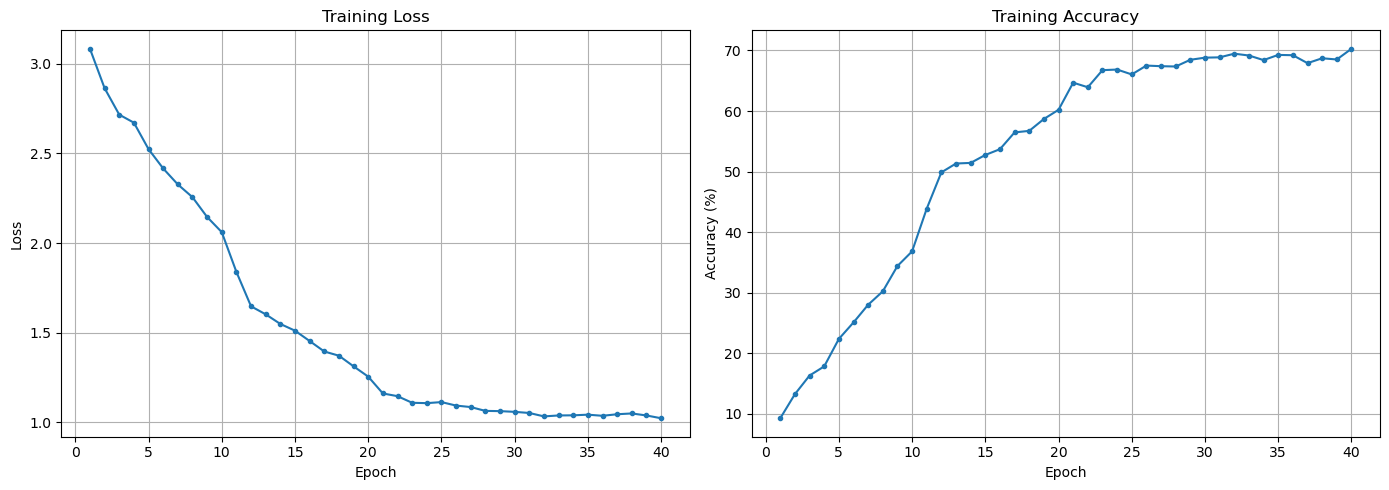

In [61]:
# ── Problem 1: Plot training curves ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, NUM_EPOCHS+1), train_losses, marker='o', markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].grid(True)

axes[1].plot(range(1, NUM_EPOCHS+1), train_accs, marker='o', markersize=3)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Training Accuracy")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [62]:
# ── Problem 1: Evaluate on test set & compute average feature norm ──

# Define feature extractor F0 (everything except the final FC layer)

#Load the best model checkpoint for evaluation
resnet18.load_state_dict(torch.load("resnet18_base20.pth", map_location=device))

class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.conv1   = model.conv1
        self.bn1     = model.bn1
        self.relu    = model.relu
        self.maxpool = model.maxpool
        self.layer1  = model.layer1
        self.layer2  = model.layer2
        self.layer3  = model.layer3
        self.layer4  = model.layer4
        self.avgpool = model.avgpool

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

F0 = FeatureExtractor(resnet18).to(device)
F0.eval()
resnet18.eval()

# Evaluate test accuracy + collect feature norms in one pass
test_correct, test_total = 0, 0
all_norms = []

with torch.no_grad():
    for images, labels in tqdm(test_loader_base, desc="Evaluating on test set"):
        images, labels = images.to(device), labels.to(device)

        # Test accuracy
        outputs = resnet18(images)
        _, preds = outputs.max(1)
        test_correct += preds.eq(labels).sum().item()
        test_total += labels.size(0)

        # Feature norms
        features = F0(images)
        norms = torch.norm(features, dim=1)
        all_norms.append(norms)

test_acc = 100.0 * test_correct / test_total
all_norms = torch.cat(all_norms)
avg_feature_norm = all_norms.mean().item()

print(f"\n=== Problem 1 Results ===")
print(f"Test Accuracy (20 base classes): {test_acc:.2f}%")
print(f"Feature dimension (f)          : {feat_dim}")
print(f"Average feature norm           : {avg_feature_norm:.4f}")

# Save F0 and G0 for later problems
G0_weight = resnet18.fc.weight.data.clone()
G0_bias   = resnet18.fc.bias.data.clone()
print(f"G0 shape: {G0_weight.shape}  (should be [{NUM_BASE_CLASSES} x {feat_dim}])")

torch.save(resnet18.state_dict(), "resnet18_base20.pth")
print("Model saved to resnet18_base20.pth")


Evaluating on test set:   0%|          | 0/62 [00:00<?, ?it/s]


=== Problem 1 Results ===
Test Accuracy (20 base classes): 42.20%
Feature dimension (f)          : 512
Average feature norm           : 24.7527
G0 shape: torch.Size([20, 512])  (should be [20 x 512])
Model saved to resnet18_base20.pth


### Problem 2

In [7]:
# ── Problem 2: Setup – datasets and helper functions ──

NUM_ALL_CLASSES = len(all_class_ids)   # 37
NUM_NEW_CLASSES = len(new_class_ids)   # 17

# Filter entries to only the new 17 classes
new_class_set     = set(new_class_ids)
train_entries_new = [(n, c) for n, c in train_entries if c in new_class_set]
test_entries_new  = [(n, c) for n, c in test_entries  if c in new_class_set]

# Dataset: new 17 classes, labels mapped via all 37 class IDs → labels fall in [20..36]
train_dataset_new_full = PetDataset(train_entries_new, all_class_ids, IMG_DIR, train_transform)
# Dataset: all 37 classes for holistic evaluation
test_dataset_all       = PetDataset(test_entries,      all_class_ids, IMG_DIR, test_transform)

train_loader_new_full = DataLoader(train_dataset_new_full, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader_all       = DataLoader(test_dataset_all,       batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"New-class train samples : {len(train_dataset_new_full)}")
print(f"All-class test  samples : {len(test_dataset_all)}")


# ── Helper: expand FC layer from n_old → n_old+n_new outputs (copy old weights) ──
def expand_fc(model, n_old, n_new, feat_dim):
    new_fc = nn.Linear(feat_dim, n_old + n_new)
    with torch.no_grad():
        new_fc.weight[:n_old].copy_(model.fc.weight)
        new_fc.bias[:n_old].copy_(model.fc.bias)
    model.fc = new_fc
    return model


# ── Helper: evaluate model on all 37 classes, report total/base/new accuracy ──
def evaluate_incremental(model, loader, n_base=20, device=device):
    model.eval()
    tot_c = tot_n = base_c = base_n = new_c = new_n = 0
    with torch.no_grad():
        for imgs, labs in tqdm(loader, desc="Evaluating", leave=False):
            imgs, labs = imgs.to(device), labs.to(device)
            preds = model(imgs).argmax(1)
            tot_c  += preds.eq(labs).sum().item();  tot_n  += labs.size(0)
            bm      = labs < n_base
            base_c += preds[bm].eq(labs[bm]).sum().item();  base_n += bm.sum().item()
            nm      = ~bm
            new_c  += preds[nm].eq(labs[nm]).sum().item();  new_n  += nm.sum().item()
    return {
        "total": 100.0 * tot_c  / tot_n,
        "base" : 100.0 * base_c / base_n if base_n > 0 else 0.0,
        "new"  : 100.0 * new_c  / new_n  if new_n  > 0 else 0.0,
    }


New-class train samples : 1695
All-class test  samples : 3669


In [12]:
# ── Problem 2 – Setting 1: Fine-tune BOTH F and G1 on new 17 classes only ──
# (Demonstrates catastrophic forgetting of the original 20 classes)

NUM_EPOCHS_INC = 20
criterion = nn.CrossEntropyLoss()

# Load base model and expand classifier: 20 → 37 outputs
model_s1 = models.resnet18(weights=None)
model_s1.fc = nn.Linear(feat_dim, NUM_BASE_CLASSES)
model_s1.load_state_dict(torch.load("resnet18_base20.pth", map_location=device))
model_s1 = expand_fc(model_s1, NUM_BASE_CLASSES, NUM_NEW_CLASSES, feat_dim).to(device)

# All parameters are trainable (backbone F and classifier G1 both update)
optimizer_s1 = optim.Adam(model_s1.parameters(), lr=1e-4)
scheduler_s1 = optim.lr_scheduler.StepLR(optimizer_s1, step_size=10, gamma=0.1)

for epoch in range(1, NUM_EPOCHS_INC + 1):
    model_s1.train()
    run_loss = correct = total = 0
    for imgs, labs in tqdm(train_loader_new_full, desc=f"S1 Epoch {epoch}/{NUM_EPOCHS_INC}", leave=False):
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer_s1.zero_grad()
        out  = model_s1(imgs)
        loss = criterion(out, labs)
        loss.backward()
        optimizer_s1.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labs).sum().item()
        total    += labs.size(0)
    scheduler_s1.step()
    print(f"S1 Epoch {epoch:02d} | Loss: {run_loss/total:.4f} | New-class Train Acc: {100*correct/total:.2f}%")

res_s1 = evaluate_incremental(model_s1, test_loader_all)
print(f"\n=== Setting 1 Results (Fine-tune F + G1 on new 17 classes) ===")
print(f"Total Accuracy      : {res_s1['total']:.2f}%")
print(f"Base 20-class Acc   : {res_s1['base']:.2f}%")
print(f"New  17-class Acc   : {res_s1['new']:.2f}%")


S1 Epoch 1/20:   0%|          | 0/53 [00:00<?, ?it/s]

S1 Epoch 01 | Loss: 3.2033 | New-class Train Acc: 9.44%


S1 Epoch 2/20:   0%|          | 0/53 [00:00<?, ?it/s]

S1 Epoch 02 | Loss: 2.3035 | New-class Train Acc: 32.04%


S1 Epoch 3/20:   0%|          | 0/53 [00:00<?, ?it/s]

...

S1 Epoch 19 | Loss: 0.7503 | New-class Train Acc: 80.24%


S1 Epoch 20/20:   0%|          | 0/53 [00:00<?, ?it/s]

S1 Epoch 20 | Loss: 0.7332 | New-class Train Acc: 81.18%


Evaluating:   0%|          | 0/115 [00:00<?, ?it/s]


=== Setting 1 Results (Fine-tune F + G1 on new 17 classes) ===
Total Accuracy      : 23.68%
Base 20-class Acc   : 0.00%
New  17-class Acc   : 51.48%


In [13]:
# ── Problem 2 – Setting 2: Keep F0 FROZEN, train only G1 on 17 classes ──
NUM_EPOCHS_INC = 20
criterion = nn.CrossEntropyLoss()

# Load base model and expand classifier: 20 → 37 outputs
model_s3 = models.resnet18(weights=None)
model_s3.fc = nn.Linear(feat_dim, NUM_BASE_CLASSES)
model_s3.load_state_dict(torch.load("resnet18_base20.pth", map_location=device))
model_s3 = expand_fc(model_s3, NUM_BASE_CLASSES, NUM_NEW_CLASSES, feat_dim).to(device)

# Freeze everything except the final FC layer
for name, param in model_s3.named_parameters():
    param.requires_grad = ('fc' in name)

# Print parameter counts
total_params     = sum(p.numel() for p in model_s3.parameters())
trainable_params = sum(p.numel() for p in model_s3.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f"\nParameter counts:")
print(f"  Total      : {total_params:,}")
print(f"  Trainable  : {trainable_params:,}  (G1 only: {NUM_ALL_CLASSES} x {feat_dim} weights + {NUM_ALL_CLASSES} biases)")
print(f"  Frozen     : {frozen_params:,}  (backbone F0)")

optimizer_s2 = optim.Adam(filter(lambda p: p.requires_grad, model_s3.parameters()), lr=1e-3)
scheduler_s2 = optim.lr_scheduler.StepLR(optimizer_s2, step_size=10, gamma=0.1)

for epoch in range(1, NUM_EPOCHS_INC + 1):
    # Keep backbone in eval() so BatchNorm running statistics are NOT updated
    model_s3.eval()
    model_s3.fc.train()

    run_loss = correct = total = 0
    for imgs, labs in tqdm(train_loader_new_full, desc=f"S2 Epoch {epoch}/{NUM_EPOCHS_INC}", leave=False):
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer_s2.zero_grad()
        out  = model_s3(imgs)
        loss = criterion(out, labs)
        loss.backward()
        optimizer_s2.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labs).sum().item()
        total    += labs.size(0)
    scheduler_s2.step()
    print(f"S2 Epoch {epoch:02d} | Loss: {run_loss/total:.4f} | New-Class Train Acc: {100*correct/total:.2f}%")

res_s2 = evaluate_incremental(model_s3, test_loader_all)
print(f"\n=== Setting 2 Results (Frozen F0, train G1 on ALL 37 classes) ===")
print(f"Total Accuracy      : {res_s2['total']:.2f}%")
print(f"Base 20-class Acc   : {res_s2['base']:.2f}%")
print(f"New  17-class Acc   : {res_s2['new']:.2f}%")

# ── Comparison: Setting 1 vs Setting 2 ──
print(f"\n{'Method':<38} {'Total':>8} {'Base 20':>10} {'New 17':>10}")
print("-" * 68)
print(f"{'S1: Fine-tune F+G1 (new 17 only)':<38} {res_s1['total']:>7.2f}% {res_s1['base']:>9.2f}% {res_s1['new']:>9.2f}%")
print(f"{'S2: Frozen F0, train G1 (new 17 only)':<38} {res_s2['total']:>7.2f}% {res_s2['base']:>9.2f}% {res_s2['new']:>9.2f}%")



Parameter counts:
  Total      : 11,195,493
  Trainable  : 18,981  (G1 only: 37 x 512 weights + 37 biases)
  Frozen     : 11,176,512  (backbone F0)


S2 Epoch 1/20:   0%|          | 0/53 [00:00<?, ?it/s]

S2 Epoch 01 | Loss: 2.5565 | New-Class Train Acc: 23.24%


S2 Epoch 2/20:   0%|          | 0/53 [00:00<?, ?it/s]

S2 Epoch 02 | Loss: 1.9842 | New-Class Train Acc: 37.35%


...

S2 Epoch 19 | Loss: 1.6785 | New-Class Train Acc: 46.84%


S2 Epoch 20/20:   0%|          | 0/53 [00:00<?, ?it/s]

S2 Epoch 20 | Loss: 1.6742 | New-Class Train Acc: 46.96%


Evaluating:   0%|          | 0/115 [00:00<?, ?it/s]


=== Setting 2 Results (Frozen F0, train G1 on ALL 37 classes) ===
Total Accuracy      : 17.55%
Base 20-class Acc   : 0.00%
New  17-class Acc   : 38.15%

Method                                    Total    Base 20     New 17
--------------------------------------------------------------------
S1: Fine-tune F+G1 (new 17 only)         23.68%      0.00%     51.48%
S2: Frozen F0, train G1 (new 17 only)    17.55%      0.00%     38.15%


In [14]:
# ── Problem 2 – Setting 2: Keep F0 FROZEN, train only G1 on ALL 37 classes ──

# Full training dataset (all 37 classes, labels 0..36)
train_dataset_all = PetDataset(train_entries, all_class_ids, IMG_DIR, train_transform)
train_loader_all  = DataLoader(train_dataset_all, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"All-class train samples : {len(train_dataset_all)}")

# Load base model and expand classifier: 20 → 37 outputs
model_s2 = models.resnet18(weights=None)
model_s2.fc = nn.Linear(feat_dim, NUM_BASE_CLASSES)
model_s2.load_state_dict(torch.load("resnet18_base20.pth", map_location=device))
model_s2 = expand_fc(model_s2, NUM_BASE_CLASSES, NUM_NEW_CLASSES, feat_dim).to(device)

# Freeze everything except the final FC layer
for name, param in model_s2.named_parameters():
    param.requires_grad = ('fc' in name)

# Print parameter counts
total_params     = sum(p.numel() for p in model_s2.parameters())
trainable_params = sum(p.numel() for p in model_s2.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f"\nParameter counts:")
print(f"  Total      : {total_params:,}")
print(f"  Trainable  : {trainable_params:,}  (G1 only: {NUM_ALL_CLASSES} x {feat_dim} weights + {NUM_ALL_CLASSES} biases)")
print(f"  Frozen     : {frozen_params:,}  (backbone F0)")

optimizer_s2 = optim.Adam(filter(lambda p: p.requires_grad, model_s2.parameters()), lr=1e-3)
scheduler_s2 = optim.lr_scheduler.StepLR(optimizer_s2, step_size=10, gamma=0.1)

for epoch in range(1, NUM_EPOCHS_INC + 1):
    # Keep backbone in eval() so BatchNorm running statistics are NOT updated
    model_s2.eval()
    model_s2.fc.train()

    run_loss = correct = total = 0
    for imgs, labs in tqdm(train_loader_all, desc=f"S2 Epoch {epoch}/{NUM_EPOCHS_INC}", leave=False):
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer_s2.zero_grad()
        out  = model_s2(imgs)
        loss = criterion(out, labs)
        loss.backward()
        optimizer_s2.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labs).sum().item()
        total    += labs.size(0)
    scheduler_s2.step()
    print(f"S2 Epoch {epoch:02d} | Loss: {run_loss/total:.4f} | All-class Train Acc: {100*correct/total:.2f}%")

res_s3 = evaluate_incremental(model_s2, test_loader_all)
print(f"\n=== Setting 2 Results (Frozen F0, train G1 on ALL 37 classes) ===")
print(f"Total Accuracy      : {res_s3['total']:.2f}%")
print(f"Base 20-class Acc   : {res_s3['base']:.2f}%")
print(f"New  17-class Acc   : {res_s3['new']:.2f}%")

# ── Comparison: Setting 1 vs Setting 2 ──
print(f"\n{'Method':<38} {'Total':>8} {'Base 20':>10} {'New 17':>10}")
print("-" * 68)
print(f"{'S1: Fine-tune F+G1 (new 17 only)':<38} {res_s1['total']:>7.2f}% {res_s1['base']:>9.2f}% {res_s1['new']:>9.2f}%")
print(f"{'S2: Frozen F0, train G1 (new 17 only)':<38} {res_s2['total']:>7.2f}% {res_s2['base']:>9.2f}% {res_s2['new']:>9.2f}%")
print(f"{'S2: Frozen F0, train G1 (all 37)':<38} {res_s3['total']:>7.2f}% {res_s3['base']:>9.2f}% {res_s3['new']:>9.2f}%")


All-class train samples : 3680

Parameter counts:
  Total      : 11,195,493
  Trainable  : 18,981  (G1 only: 37 x 512 weights + 37 biases)
  Frozen     : 11,176,512  (backbone F0)


S2 Epoch 1/20:   0%|          | 0/115 [00:00<?, ?it/s]

S2 Epoch 01 | Loss: 2.2296 | All-class Train Acc: 38.64%


S2 Epoch 2/20:   0%|          | 0/115 [00:00<?, ?it/s]

S2 Epoch 02 | Loss: 1.9980 | All-class Train Acc: 41.77%


...

S2 Epoch 19 | Loss: 1.7123 | All-class Train Acc: 50.03%


S2 Epoch 20/20:   0%|          | 0/115 [00:00<?, ?it/s]

S2 Epoch 20 | Loss: 1.7115 | All-class Train Acc: 49.35%


Evaluating:   0%|          | 0/115 [00:00<?, ?it/s]


=== Setting 2 Results (Frozen F0, train G1 on ALL 37 classes) ===
Total Accuracy      : 27.53%
Base 20-class Acc   : 32.41%
New  17-class Acc   : 21.80%

Method                                    Total    Base 20     New 17
--------------------------------------------------------------------
S1: Fine-tune F+G1 (new 17 only)         23.68%      0.00%     51.48%
S2: Frozen F0, train G1 (new 17 only)    17.55%      0.00%     38.15%
S2: Frozen F0, train G1 (all 37)         27.53%     32.41%     21.80%


### Problem 3: Mitigating Catastrophic Forgetting

In [66]:
# ── Problem 3: Step 1 – Extract F0 features for base 20 classes and compute per-class statistics ──
# F0 from Problem 1 is still valid (resnet18 weights unchanged; Problems 2 used separate objects)

F0.eval()

# Use no-augmentation transform so features are deterministic
train_dataset_base_noaug = PetDataset(train_entries, base_class_ids, IMG_DIR, test_transform)
train_loader_base_noaug  = DataLoader(train_dataset_base_noaug, batch_size=BATCH_SIZE,
                                       shuffle=False, num_workers=0)

# Accumulate feature vectors per class (labels 0..19)
base_feat_dict = {c: [] for c in range(NUM_BASE_CLASSES)}

with torch.no_grad():
    for imgs, labs in tqdm(train_loader_base_noaug, desc="Extracting base-class features"):
        imgs  = imgs.to(device)
        feats = F0(imgs)                                   # [B, 512]
        for feat, lab in zip(feats.cpu(), labs.tolist()):
            base_feat_dict[lab].append(feat)

# Compute µc and σ²c (element-wise variance) for each class c
class_mu  = {}   # c → tensor [feat_dim]
class_var = {}   # c → tensor [feat_dim]

for c in range(NUM_BASE_CLASSES):
    feats_c    = torch.stack(base_feat_dict[c])            # [Nc, 512]
    mu         = feats_c.mean(dim=0)
    var        = ((feats_c - mu) ** 2).mean(dim=0)         # element-wise variance
    class_mu[c]  = mu
    class_var[c] = var

print("Per-class feature statistics computed.")
print(f"Feature dimension    : {feat_dim}")
print(f"Samples per class    : min={min(len(v) for v in base_feat_dict.values())}, "
      f"max={max(len(v) for v in base_feat_dict.values())}")
print(f"Mean feature norm    : {torch.stack(list(class_mu.values())).norm(dim=1).mean().item():.4f}")


Extracting base-class features:   0%|          | 0/63 [00:00<?, ?it/s]

Per-class feature statistics computed.
Feature dimension    : 512
Samples per class    : min=93, max=100
Mean feature norm    : 22.4032


In [75]:
# ── Problem 3: Step 2 – Generate synthetic features + combine with real new-class features ──

N_SYNTHETIC = 5   # synthetic samples per base class (as specified in the assignment)
EPS = 1e-4        # regularisation added to covariance diagonal for numerical stability

# Sample f̃ ~ N(µc, Σc) using full covariance for each base class
synthetic_samples = []   # list of (feat_tensor [512], label_int 0..19)

for c in range(NUM_BASE_CLASSES):
    feats_c = torch.stack(base_feat_dict[c])          # (Nc, 512) – stacked from Step 1
    mu      = feats_c.mean(dim=0)                     # (512,)
    cov     = torch.cov(feats_c.T)                    # (512, 512) – full covariance
    cov     = cov + EPS * torch.eye(cov.size(0))      # regularise: ensure positive-definite

    dist = torch.distributions.MultivariateNormal(mu, covariance_matrix=cov)
    for _ in range(N_SYNTHETIC):
        synth = dist.sample()                         # (512,)
        synthetic_samples.append((synth, c))

print(f"Synthetic samples generated : {len(synthetic_samples)}  "
      f"({N_SYNTHETIC} per class × {NUM_BASE_CLASSES} classes)")

# Extract real features from new 17 class training images using frozen F0
# train_entries_new filtered to new 17 classes; all_class_ids mapping → labels 20..36
train_loader_new_noaug = DataLoader(
    PetDataset(train_entries_new, all_class_ids, IMG_DIR, test_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

real_new_samples = []   # list of (feat_tensor [512], label_int  20..36)
F0.eval()
with torch.no_grad():
    for imgs, labs in tqdm(train_loader_new_noaug, desc="Extracting new-class features"):
        imgs  = imgs.to(device)
        feats = F0(imgs)
        for feat, lab in zip(feats.cpu(), labs.tolist()):
            real_new_samples.append((feat, lab))

print(f"Real new-class samples      : {len(real_new_samples)}")
print(f"Combined dataset size       : {len(synthetic_samples) + len(real_new_samples)}")


# Dataset of pre-extracted (feature_vector, label) pairs
class FeatureDataset(Dataset):
    def __init__(self, pairs):
        self.feats  = torch.stack([p[0] for p in pairs])
        self.labels = torch.tensor([p[1] for p in pairs], dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.feats[idx], self.labels[idx]

combined_dataset = FeatureDataset(synthetic_samples + real_new_samples)
combined_loader  = DataLoader(combined_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)


Synthetic samples generated : 100  (5 per class × 20 classes)


Extracting new-class features:   0%|          | 0/53 [00:00<?, ?it/s]

Real new-class samples      : 1695
Combined dataset size       : 1795


In [76]:
# ── Problem 3: Step 3 – Train G1 on combined features, evaluate, compare ──

# Build expanded G1 (37 outputs); initialise old-class rows from saved G0
G1_p3 = nn.Linear(feat_dim, NUM_ALL_CLASSES).to(device)
with torch.no_grad():
    G1_p3.weight[:NUM_BASE_CLASSES].copy_(G0_weight)   # saved in Problem 1
    G1_p3.bias[:NUM_BASE_CLASSES].copy_(G0_bias)

optimizer_p3 = optim.Adam(G1_p3.parameters(), lr=1e-3)
scheduler_p3 = optim.lr_scheduler.StepLR(optimizer_p3, step_size=20, gamma=0.1)

NUM_EPOCHS_P3 = 50

for epoch in range(1, NUM_EPOCHS_P3 +  1):
    G1_p3.train()
    run_loss = correct = total = 0
    for feats, labs in combined_loader:
        feats, labs = feats.to(device), labs.to(device)
        optimizer_p3.zero_grad()
        out  = G1_p3(feats)
        loss = criterion(out, labs)
        loss.backward()
        optimizer_p3.step()
        run_loss += loss.item() * feats.size(0)
        correct  += out.argmax(1).eq(labs).sum().item()
        total    += labs.size(0)
    scheduler_p3.step()
    if epoch % 10 == 0:
        print(f"P3 Epoch {epoch:02d} | Loss: {run_loss/total:.4f} | Train Acc: {100*correct/total:.2f}%")

# ── Evaluation: compose F0 (frozen) + G1_p3 ──
class FrozenBackboneModel(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head     = head
    def forward(self, x):
        return self.head(self.backbone(x))

eval_model_p3 = FrozenBackboneModel(F0, G1_p3)
res_p3 = evaluate_incremental(eval_model_p3, test_loader_all)

print(f"\n=== Problem 3 Results (Feature Distribution Replay) ===")
print(f"Total Accuracy      : {res_p3['total']:.2f}%")
print(f"Base 20-class Acc   : {res_p3['base']:.2f}%")
print(f"New  17-class Acc   : {res_p3['new']:.2f}%")

# ── Final three-way comparison ──
print(f"\n{'Method':<44} {'Total':>8} {'Base 20':>10} {'New 17':>10}")
print("-" * 74)
print(f"{'P2-S1 : Fine-tune F+G1 (new only)':<44} {res_s1['total']:>7.2f}% {res_s1['base']:>9.2f}% {res_s1['new']:>9.2f}%")
print(f"{'P2-S2 : Frozen F0, train G1 (new only)':<44} {res_s2['total']:>7.2f}% {res_s2['base']:>9.2f}% {res_s2['new']:>9.2f}%")
print(f"{'P3    : Frozen F0 + feature replay':<44} {res_p3['total']:>7.2f}% {res_p3['base']:>9.2f}% {res_p3['new']:>9.2f}%")

P3 Epoch 10 | Loss: 1.8163 | Train Acc: 42.95%
P3 Epoch 20 | Loss: 1.6666 | Train Acc: 49.64%
P3 Epoch 30 | Loss: 1.5673 | Train Acc: 51.87%
P3 Epoch 40 | Loss: 1.5565 | Train Acc: 52.65%
P3 Epoch 50 | Loss: 1.5445 | Train Acc: 53.31%


Evaluating:   0%|          | 0/115 [00:00<?, ?it/s]


=== Problem 3 Results (Feature Distribution Replay) ===
Total Accuracy      : 21.15%
Base 20-class Acc   : 5.20%
New  17-class Acc   : 39.87%

Method                                          Total    Base 20     New 17
--------------------------------------------------------------------------
P2-S1 : Fine-tune F+G1 (new only)              23.52%      0.00%     51.13%
P2-S2 : Frozen F0, train G1 (new only)         27.23%     32.86%     20.62%
P3    : Frozen F0 + feature replay             21.15%      5.20%     39.87%
